In [ ]:
from google.colab import files
files.upload()


Saving StudentsPerformance.csv to StudentsPerformance.csv


{'StudentsPerformance.csv': b"gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score\r\nfemale,group B,bachelor's degree,standard,none,72,72,74\r\nfemale,group C,some college,standard,completed,69,90,88\r\nfemale,group B,master's degree,standard,none,90,95,93\r\nmale,group A,associate's degree,free/reduced,none,47,57,44\r\nmale,group C,some college,standard,none,76,78,75\r\nfemale,group B,associate's degree,standard,none,71,83,78\r\nfemale,group B,some college,standard,completed,88,95,92\r\nmale,group B,some college,free/reduced,none,40,43,39\r\nmale,group D,high school,free/reduced,completed,64,64,67\r\nfemale,group B,high school,free/reduced,none,38,60,50\r\nmale,group C,associate's degree,standard,none,58,54,52\r\nmale,group D,associate's degree,standard,none,40,52,43\r\nfemale,group B,high school,standard,none,65,81,73\r\nmale,group A,some college,standard,completed,78,72,70\r\nfemale,group A,master's degree,standard,n

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


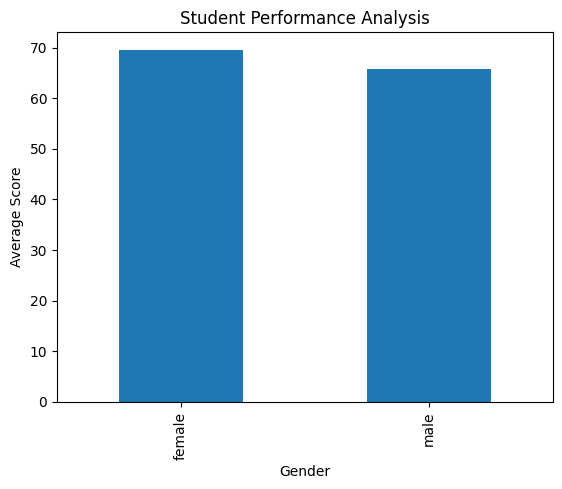

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Data Preparation
df = pd.read_csv("StudentsPerformance.csv")
df.head()
df.info()
df.fillna(0, inplace=True)
df.isnull().sum()
df["average_score"] = df[["math score","reading score","writing score"]].mean(axis=1)
df.describe()
gender_avg = df.groupby("gender")["average_score"].mean()
gender_avg
X = df[["math score","reading score"]]
y = df["writing score"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)
model.score(X_test, y_test)
gender_avg.plot(kind="bar")
plt.xlabel("Gender")
plt.ylabel("Average Score")
plt.title("Student Performance Analysis")
plt.show()
